In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def read_mat_data(filepath):
    import scipy.io
    rd = scipy.io.loadmat(filepath) # load the mat file
    PDATA = rd['PDATA']
    TWT = rd['TWT']
    
    return PDATA, TWT

In [3]:
# load TWT vector
[PDATA, TWT] = read_mat_data('/Users/jukesliu/Documents/POSTDOC/snow-radar/RME2009/ProcessedMay25_xyz/PDATA/pdriftzigzag_8_PDATA.mat')
TWT = TWT.flatten()
TWT = TWT[int(len(TWT)/2):]
TWT.shape

(8192,)

In [5]:
TWT

array([0.00000000e+00, 1.14186605e-11, 2.28373210e-11, ...,
       9.35074107e-08, 9.35188293e-08, 9.35302480e-08])

In [4]:
TWT_interval = np.diff(TWT)[0]
print(TWT_interval)

1.1418660481770834e-11


# Clean up CSV file

In [4]:
file_df = pd.read_csv('/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/final_radar_picks/GM2020_rdpicks_all.csv'
                      ,index_col=0)
file_df

,x,y,Isurf,Iground,rd_xidx,TWT_surf,TWT_ground,rd_id,radar_depth_cm,lidar_depth,transect_name,collection_date,Unnamed: 0.1,Unnamed: 0.1.1
0,741911.781848,4.324354e+06,416.0,1168.0,141.0,4.225000e-09,1.186250e-08,rd01,85.196406,86.274414,1N6_5N10,20200128,NaN,NaN
1,741911.781848,4.324354e+06,416.0,1170.0,142.0,4.225000e-09,1.188281e-08,rd01,85.444219,86.274414,1N6_5N10,20200128,NaN,NaN
2,741911.781848,4.324354e+06,416.0,1171.0,143.0,4.225000e-09,1.189297e-08,rd01,85.568125,86.274414,1N6_5N10,20200128,NaN,NaN
3,741911.801295,4.324354e+06,416.0,1172.0,144.0,4.225000e-09,1.190313e-08,rd01,85.692031,86.274414,1N6_5N10,20200128,NaN,NaN
4,741911.801295,4.324354e+06,416.0,1174.0,145.0,4.225000e-09,1.192344e-08,rd01,85.939844,86.274414,1N6_5N10,20200128,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267122,750191.547345,4.322257e+06,493.0,1312.0,3011.0,5.010040e-09,1.333301e-08,rd61,91.558179,113.520500,NorthLinee2,20200212,NaN,NaN
1267123,750191.569064,4.322258e+06,492.0,1312.0,3012.0,4.999878e-09,1.333301e-08,rd61,91.682159,113.520500,NorthLinee2,20200212,NaN,NaN
1267124,750191.569064,4.322258e+06,492.0,1312.0,3013.0,4.999878e-09,1.333301e-08,rd61,91.682159,113.520500,NorthLinee2,20200212,NaN,NaN
1267125,750191.569064,4.322258e+06,492.0,1312.0,3014.0,4.999878e-09,1.333301e-08,rd61,91.682159,114.399410,NorthLinee2,20200212,NaN,NaN


In [8]:
# shift the ground index
# # add in TWT
# TWT_surf = TWT[(file_df.Isurf).astype(int)]
# TWT_ground = TWT[(file_df.Iground).astype(int)]
# file_df['TWT_surf'] = TWT_surf; file_df['TWT_ground'] = TWT_ground

# # rename certain columns
# cleaned_df = file_df.rename(columns={'x': 'UTMx', 'y': 'UTMy',# 'x_idx': 'rd_xidx',
#                                         #'depth': 'radar_depth_cm'
#                                        })
cleaned_df = cleaned_df[["collection_date","transect_name",
                         "rd_id", "UTMx", "UTMy", 
                         "Isurf", "Iground", "TWT_surf", "TWT_ground",
                         "radar_depth_cm"]]

# cleaned_df = file_df[["rd_id", "UTMx", "UTMy", "Isurf", "Iground", "TWT_surf", "TWT_ground","radar_depth_cm"]] # grab the relevant subset
# cleaned_df = cleaned_df.sort_values(by='rd_id').reset_index(drop=True)
# cleaned_df
# # rename certain columns
# cleaned_df = cleaned_df.rename(columns={'x': 'UTMx', 'y': 'UTMy', 'x_idx': 'rd_xidx', 
#                                         'depth': 'radar_depth_cm'})

# # # round the radar depth cm to the nearest integer
# # cleaned_df['radar_depth_cm'] = np.round(cleaned_df['radar_depth_cm']).astype(int)

# # # add depth shift!
# # cleaned_df.radar_depth_cm = cleaned_df.radar_depth_cm - 41

# # overwrite
cleaned_df.to_csv('/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/final_radar_picks/GM2020_rdpicks_all_noheader.csv')
cleaned_df

,collection_date,transect_name,rd_id,UTMx,UTMy,Isurf,Iground,TWT_surf,TWT_ground,radar_depth_cm
0,20200128,1N6_5N10,rd01,741911.781848,4.324354e+06,416.0,1168.0,4.225000e-09,1.186250e-08,85.196406
1,20200128,1N6_5N10,rd01,741911.781848,4.324354e+06,416.0,1170.0,4.225000e-09,1.188281e-08,85.444219
2,20200128,1N6_5N10,rd01,741911.781848,4.324354e+06,416.0,1171.0,4.225000e-09,1.189297e-08,85.568125
3,20200128,1N6_5N10,rd01,741911.801295,4.324354e+06,416.0,1172.0,4.225000e-09,1.190313e-08,85.692031
4,20200128,1N6_5N10,rd01,741911.801295,4.324354e+06,416.0,1174.0,4.225000e-09,1.192344e-08,85.939844
...,...,...,...,...,...,...,...,...,...,...
1267122,20200212,NorthLinee2,rd61,750191.547345,4.322257e+06,493.0,1312.0,5.010040e-09,1.333301e-08,91.558179
1267123,20200212,NorthLinee2,rd61,750191.569064,4.322258e+06,492.0,1312.0,4.999878e-09,1.333301e-08,91.682159
1267124,20200212,NorthLinee2,rd61,750191.569064,4.322258e+06,492.0,1312.0,4.999878e-09,1.333301e-08,91.682159
1267125,20200212,NorthLinee2,rd61,750191.569064,4.322258e+06,492.0,1312.0,4.999878e-09,1.333301e-08,91.682159


## Shift index and TWT values based off post-processing

41.53846153846155 m  =  323 pixels

In [22]:
depth_shift = 32.5
velocity = 222477428*100 # cm/s
pixel_shift = round(depth_shift*2/velocity/TWT_interval)
print(pixel_shift)

256


In [60]:
file_df = pd.read_csv('/Users/jukesliu/Documents/POSTDOC/snow-radar/RME_output/all_rds_lidar0removed_shifted.csv',index_col=0)
file_df['UTMx'] = file_df.x; file_df['UTMy'] = file_df.y
# # shift the ground index
# file_df.Iground = file_df.Iground-pixel_shift

# # grab the new TWT ground
# TWT_ground = TWT[(file_df.Iground).astype(int)]
# file_df['TWT_ground'] = TWT_ground

# # re-grab the surface index
# TWT_surf = TWT[(file_df.Isurf).astype(int)]
# file_df['TWT_surf'] = TWT_surf

# # # recalculate depths using new velocity
# # shifted_depths = (file_df.TWT_ground-file_df.TWT_surf)*velocity/2
file_df.radar_depth_cm = np.array(file_df.radar_depth_cm)+12

# # drop rd_idx
# file_df = file_df.drop(columns=['Unnamed: 0.1','Unnamed: 0.1.1','Unnamed: 0.1.1.1'])
file_df = file_df.drop(columns=['x','y'])
file_df

,Isurf,Iground,rd_xidx,TWT_surf,TWT_ground,rd_id,radar_depth_cm,lidar_depth,UTMx,UTMy
0,533.0,1562.0,2646.0,6.086146e-09,1.783595e-08,rd29,130.412636,122.296143,519812.713912,4.768505e+06
1,534.0,1561.0,2647.0,6.097565e-09,1.782453e-08,rd29,130.158597,122.296143,519812.707143,4.768505e+06
2,534.0,1561.0,2648.0,6.097565e-09,1.782453e-08,rd29,130.158597,122.296143,519812.700370,4.768505e+06
3,534.0,1560.0,2649.0,6.097565e-09,1.781311e-08,rd29,130.031577,122.296143,519812.693603,4.768505e+06
4,534.0,1560.0,2650.0,6.097565e-09,1.781311e-08,rd29,130.031577,122.296143,519812.686837,4.768505e+06
...,...,...,...,...,...,...,...,...,...,...
115914,548.0,3026.0,4988.0,6.257426e-09,3.455287e-08,rd15,314.464197,209.631348,519762.642860,4.768250e+06
115915,548.0,3024.0,4989.0,6.257426e-09,3.453003e-08,rd15,314.210157,209.631348,519762.636415,4.768250e+06
115916,548.0,3022.0,4990.0,6.257426e-09,3.450719e-08,rd15,313.956118,209.631348,519762.629969,4.768250e+06
115917,548.0,3019.0,4991.0,6.257426e-09,3.447294e-08,rd15,313.575059,209.631348,519762.623519,4.768250e+06


0.9373571803213743
22.556915004687102


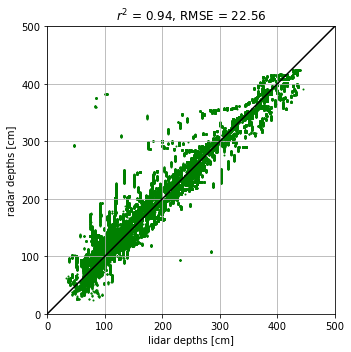

In [61]:
# plot and recalculate R2 and RMSE
from sklearn.metrics import r2_score, mean_squared_error 
all_filtered_df = file_df

X = all_filtered_df.lidar_depth
def linear_regression_line(slope, intercept):
    return slope * X + intercept
r2 = r2_score(all_filtered_df.radar_depth_cm,linear_regression_line(1, 0))
rmse = np.sqrt(mean_squared_error(all_filtered_df.radar_depth_cm, linear_regression_line(1, 0)))
print(r2)
print(rmse)

# replot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(file_df.lidar_depth, file_df.radar_depth_cm, s=1,c='g')
plt.plot([0,500],[0,500], 'k-')
plt.xlim(0,500); plt.ylim(0,500)
ax.set_title('$r^2$ = '+str(round(r2,2))+', RMSE = '+str(round(rmse,2)))
plt.ylabel('radar depths [cm]'); plt.xlabel('lidar depths [cm]')
plt.gca().set_aspect('equal'); plt.grid()
plt.tight_layout()
plt.savefig('/Users/jukesliu/Documents/POSTDOC/snow-radar/RME_output/1to1_radar_lidar_r2_rmse_plot.jpg',dpi=300)
plt.show()

In [62]:
# write to CSV
file_df.to_csv('/Users/jukesliu/Documents/POSTDOC/snow-radar/RME_output/all_rds_lidar0removed_shifted.csv')
file_df.to_csv('/Users/jukesliu/Documents/POSTDOC/snow-radar/data_submission/RME2009_fulldata/rdpicks_1000scale_100size_1mod_noheader.csv')